In [1]:
import torch
from PIL import Image
from huggingface_hub import hf_hub_download
import sys
from transformers import AutoTokenizer, AutoModel
import torch
import geopandas as gpd
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

from scipy.spatial.distance import pdist, squareform
from scipy.cluster.hierarchy import linkage, dendrogram
import seaborn as sns

from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances
from sklearn.cluster import KMeans
import matplotlib.patches as mpatches


from matplotlib.patches import Patch

sys.path.append('./satclip/satclip')
from sklearn.neighbors import KNeighborsClassifier


from load import get_satclip


device = "cuda" if torch.cuda.is_available() else "cpu"

location_model = get_satclip(
    hf_hub_download("microsoft/SatCLIP-ViT16-L40", "satclip-vit16-l40.ckpt"),
    device=device,
) 

gdf = gpd.read_file("gpkgs/bda_2020_patches_2024_classified.gpkg")

aez_number_to_class_label = {}
with open("LR/aez/AEZ_57classes.clr", "r") as infile:
    for line in infile:
        parts = line.strip().split()
        aez_number_to_class_label[int(parts[0])] = " ".join(parts[5:])

aez_number_to_class_label[0] = "Unclassified"





/home/nathan/Desktop/BDA_integration/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


using pretrained moco vit16


In [2]:

tokenizer = AutoTokenizer.from_pretrained('sentence-transformers/all-MiniLM-L6-v2')
model = AutoModel.from_pretrained('sentence-transformers/all-MiniLM-L6-v2')

def embed(text):
    inputs = tokenizer(text, return_tensors='pt', padding=True, truncation=True)
    with torch.no_grad():
        outputs = model(**inputs)
    # Mean pooling
    embeddings = outputs.last_hidden_state.mean(dim=1)
    return embeddings[0].numpy()

classes = gdf["aez_class"].unique()
class_embeddings = {  
    c: embed(c) for c in classes
}



In [3]:
def geom_to_torch_centroid(geom):
    x,y = geom.centroid.xy
    c = torch.tensor([x[0],y[0]]).unsqueeze(dim=0)
    return c

def embed_dataframe(gdf,location_model,class_to_embedding,use_text_embeddings=True):
    device = "cuda" if torch.cuda.is_available() else "cpu"

    centroids = torch.squeeze(torch.stack([geom_to_torch_centroid(gdf.iloc[i].geometry) for i in range(len(gdf))], dim=0))

    centroids = centroids.to(device).double()
    location_model = location_model.to(device)

    location_model.eval()
    with torch.no_grad():
        spatial_embeddings = location_model(centroids).detach().cpu()
    if use_text_embeddings:
        class_embeddings = torch.squeeze(torch.stack(list(gdf["aez_class"].apply(lambda x: torch.tensor(class_to_embedding[x]))), dim=0)).cpu()

        retval = torch.cat((spatial_embeddings, class_embeddings), dim=1).cpu()

        return retval
    return spatial_embeddings


In [4]:
def create_dataset(gdf, use_text_embeddings=True, n_classes=None, limit_count=True, sample_count=1000):
    if limit_count: 
        count_df = gdf["aez_class"].value_counts()
        classes_to_use = list(count_df[(count_df.values >= sample_count) & (count_df.index != "Unclassified")].index)
    else:
        classes_to_use = list(gdf["aez_class"].unique())
        classes_to_use.remove("Unclassified")
    if n_classes:
        classes_to_use = classes_to_use[:n_classes]
    X = []
    y = []

    aez_class_label_to_number = {
        aez_number_to_class_label[k]: k for k in aez_number_to_class_label
    }

    for c in classes_to_use:
        sample = gdf[gdf["aez_class"] == c].sample(sample_count, replace=True)

        inner_y = torch.tensor(list(sample["aez_class"].apply(lambda x: aez_class_label_to_number[x])))
        inner_X = embed_dataframe(sample, location_model, class_embeddings, use_text_embeddings)

        X.append(inner_X)
        y.append(inner_y)

    X = torch.cat(X, 0)
    y = torch.cat(y,0)

    return X,y,len(classes_to_use)


X,y,n_classes = create_dataset(gdf, limit_count=False, use_text_embeddings=False)

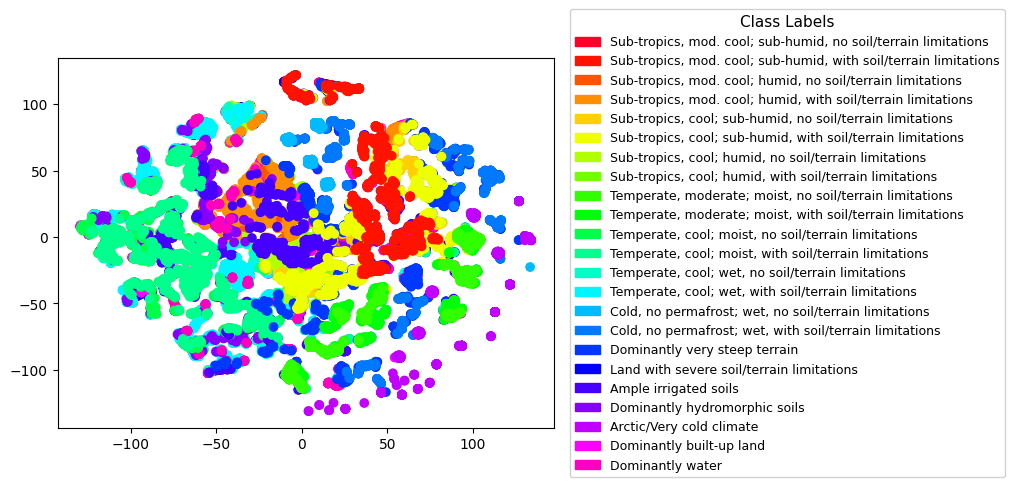

In [5]:

from matplotlib import pyplot as plt
import numpy as np


pca = PCA(n_components=100)
tsne = TSNE(n_components=2)

X_reduced = pca.fit_transform(X)
X_embedded = tsne.fit_transform(X_reduced)

classes = list(torch.unique(y))
colors = plt.cm.gist_rainbow(np.linspace(0, 1, len(np.unique(y))))
 
plt_x = [x[0] for x in X_embedded]
plt_y = [x[1] for x in X_embedded]

plt.scatter(
    plt_x, plt_y, c=[colors[classes.index(i)] for i in y]
)

legend_labels = [aez_number_to_class_label[lab] for lab in np.unique(y)]
handles = [mpatches.Patch(color=c, label=lab) for c,lab in zip(colors,[aez_number_to_class_label[lab] for lab in np.unique(y)])]


plt.legend(handles=handles,
        loc='center left', 
        bbox_to_anchor=(1.02, 0.5),
        fontsize=9,
        framealpha=0.9,
        title='Class Labels',
        title_fontsize=11)

In [6]:
def get_class_centroids(X,y):
    unique_labels = np.array(torch.unique(y))

    np_X = np.array(X)
    
    unique_labels = np.unique(y)
    centroids = np.array([
        np_X[y == label].mean(axis=0) 
        for label in unique_labels
    ])
    return centroids, unique_labels

centroids, labels = get_class_centroids(X,y)
text_labels = [aez_number_to_class_label[lab] for lab in labels]
labels

/tmp/ipykernel_472297/2048871702.py:2: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  unique_labels = np.array(torch.unique(y))
/tmp/ipykernel_472297/2048871702.py:4: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  np_X = np.array(X)


array([21, 22, 23, 24, 27, 28, 29, 30, 33, 34, 39, 40, 41, 42, 47, 48, 49,
       50, 51, 52, 55, 56, 57])

In [7]:
centroids.shape

(23, 256)

In [8]:
sim_matrix = cosine_similarity(centroids)
sim_matrix.shape

(23, 23)

In [9]:
centroids.shape

(23, 256)

In [10]:
def plot_similarity_matrix(sim_matrix, labels, aez_number_to_class_label, 
                          title='Class Similarity Matrix', 
                          cmap='viridis', figsize=(10, 8), annot=True):
    """
    Plot similarity matrix as a heatmap with hierarchical clustering.
    
    Args:
        sim_matrix: (n_classes, n_classes) similarity matrix
        labels: list of class labels
        aez_number_to_class_label: dictionary mapping labels to their descriptions
        title: plot title
        cmap: colormap
        figsize: figure size
        annot: whether to annotate cells with values
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(figsize[0]*2, figsize[1]))
    
    # Plot 1: Regular heatmap
    sns.heatmap(sim_matrix, 
                xticklabels=labels, 
                yticklabels=labels,
                cmap=cmap, 
                annot=annot,
                fmt='.2f',
                square=True,
                cbar_kws={'label': 'Similarity'},
                ax=ax1)
    ax1.set_title(f'{title} (Original Order)')
    
    # Plot 2: Clustered heatmap
    # Convert similarity to distance for clustering
    dist_matrix = 1 - sim_matrix
    np.fill_diagonal(dist_matrix, 0)  # Ensure diagonal is 0
    
    # Perform hierarchical clustering
    condensed_dist = squareform(dist_matrix, checks=False)
    linkage_matrix = linkage(condensed_dist, method='ward')
    
    # Get dendrogram order
    dend = dendrogram(linkage_matrix, no_plot=True)
    order = dend['leaves']
    
    # Reorder matrix
    sim_matrix_clustered = sim_matrix[order, :][:, order]
    labels_clustered = [labels[i] for i in order]
    
    sns.heatmap(sim_matrix_clustered,
                xticklabels=labels_clustered,
                yticklabels=labels_clustered,
                cmap=cmap,
                annot=annot,
                fmt='.2f',
                square=True,
                cbar_kws={'label': 'Similarity'},
                ax=ax2)
    ax2.set_title(f'{title} (Hierarchically Clustered)')
    
    # Create legend
    legend_elements = [Patch(facecolor='none', edgecolor='none', 
                            label=f'{label}: {aez_number_to_class_label[label]}') 
                      for label in labels]
    
    fig.legend(handles=legend_elements, title='Class Labels', 
              bbox_to_anchor=(0.85, 0.5), loc='center left', 
              frameon=True, fontsize=9)
    
    plt.tight_layout()
    plt.subplots_adjust(right=0.85)  # Make room for legend
    return fig, order


def plot_dendrogram(centroids, labels, aez_number_to_class_label, metric='euclidean'):
    # Compute distance matrix
    condensed_dist = pdist(centroids, metric=metric)
    linkage_matrix = linkage(condensed_dist, method='ward')
    
    # Plot dendrogram
    fig = plt.figure(figsize=(18, 12))
    dendrogram(linkage_matrix, labels=labels, leaf_font_size=10)
    plt.title('Hierarchical Clustering Dendrogram of AEZ Classes')
    plt.xlabel('AEZ Class')
    plt.ylabel('Distance')
    plt.xticks(rotation=45, ha='right')
    
    # Create legend
    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor='none', edgecolor='none',
                            label=f'{label}: {aez_number_to_class_label[label]}')
                      for label in labels]
    
    plt.legend(handles=legend_elements, title='Class Labels',
              bbox_to_anchor=(1.0, 0.5), loc='center left',
              frameon=True, fontsize=9)
    
    plt.tight_layout()
    plt.subplots_adjust(right=0.85)  # Make room for legend
    return fig

(<Figure size 2000x800 with 4 Axes>,
 [20,
  14,
  15,
  0,
  1,
  8,
  9,
  16,
  4,
  5,
  19,
  10,
  11,
  13,
  12,
  21,
  2,
  3,
  6,
  7,
  18,
  17,
  22])

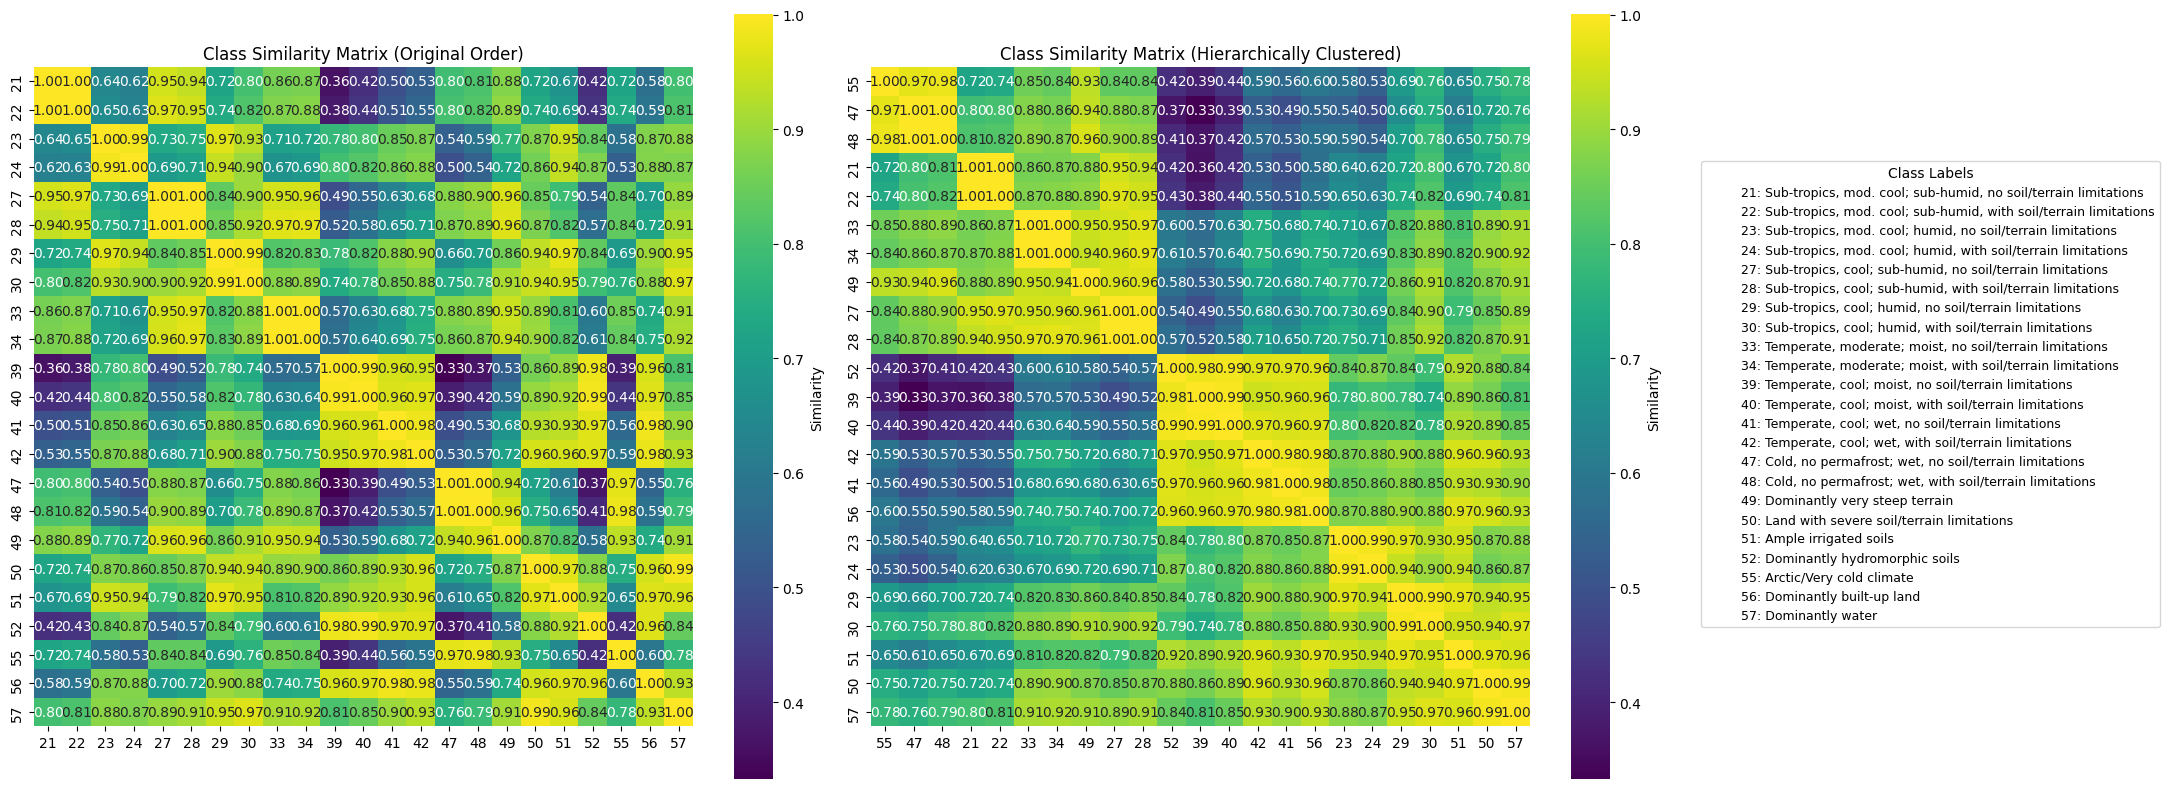

In [11]:
plot_similarity_matrix(sim_matrix, labels, aez_number_to_class_label)

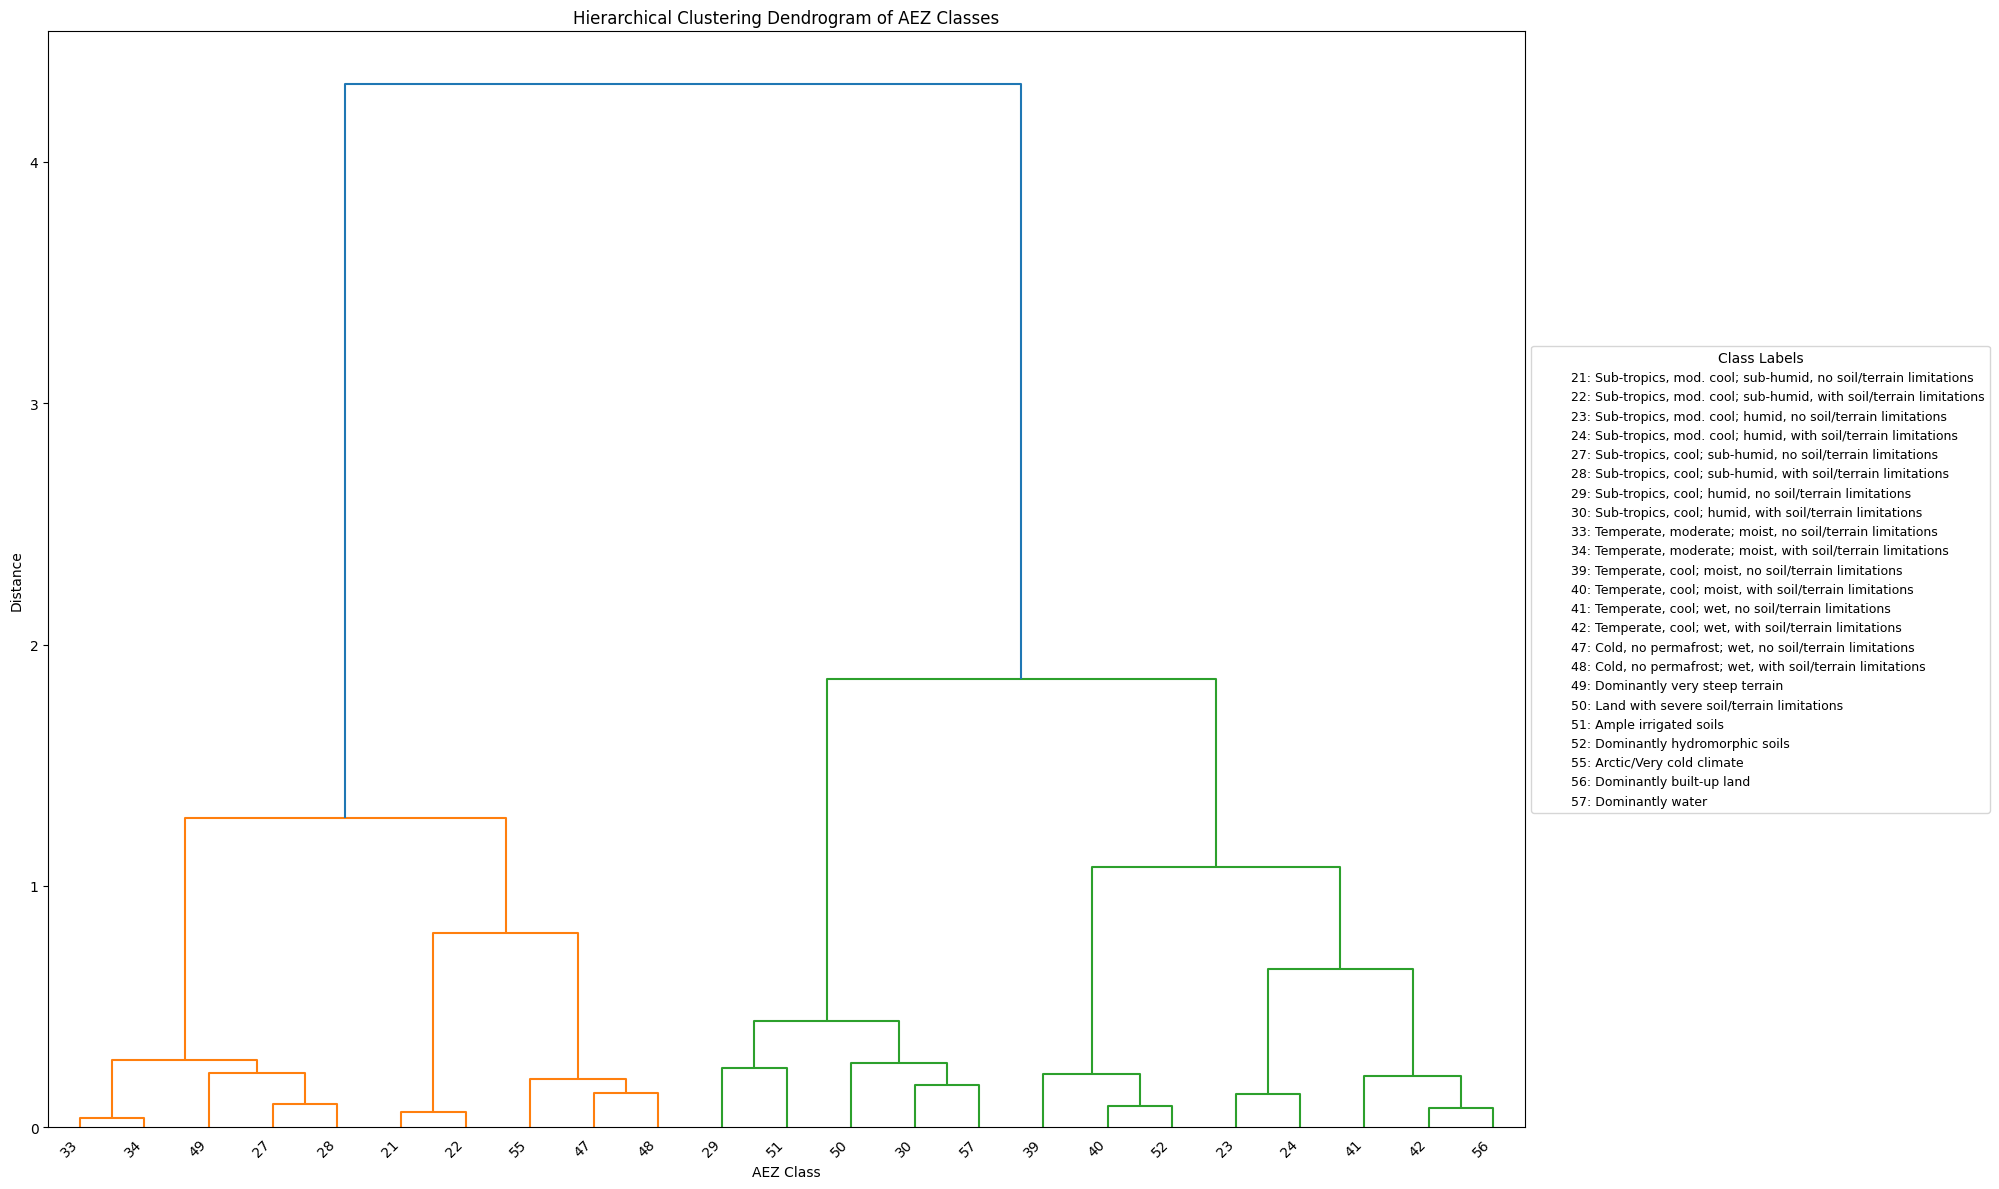

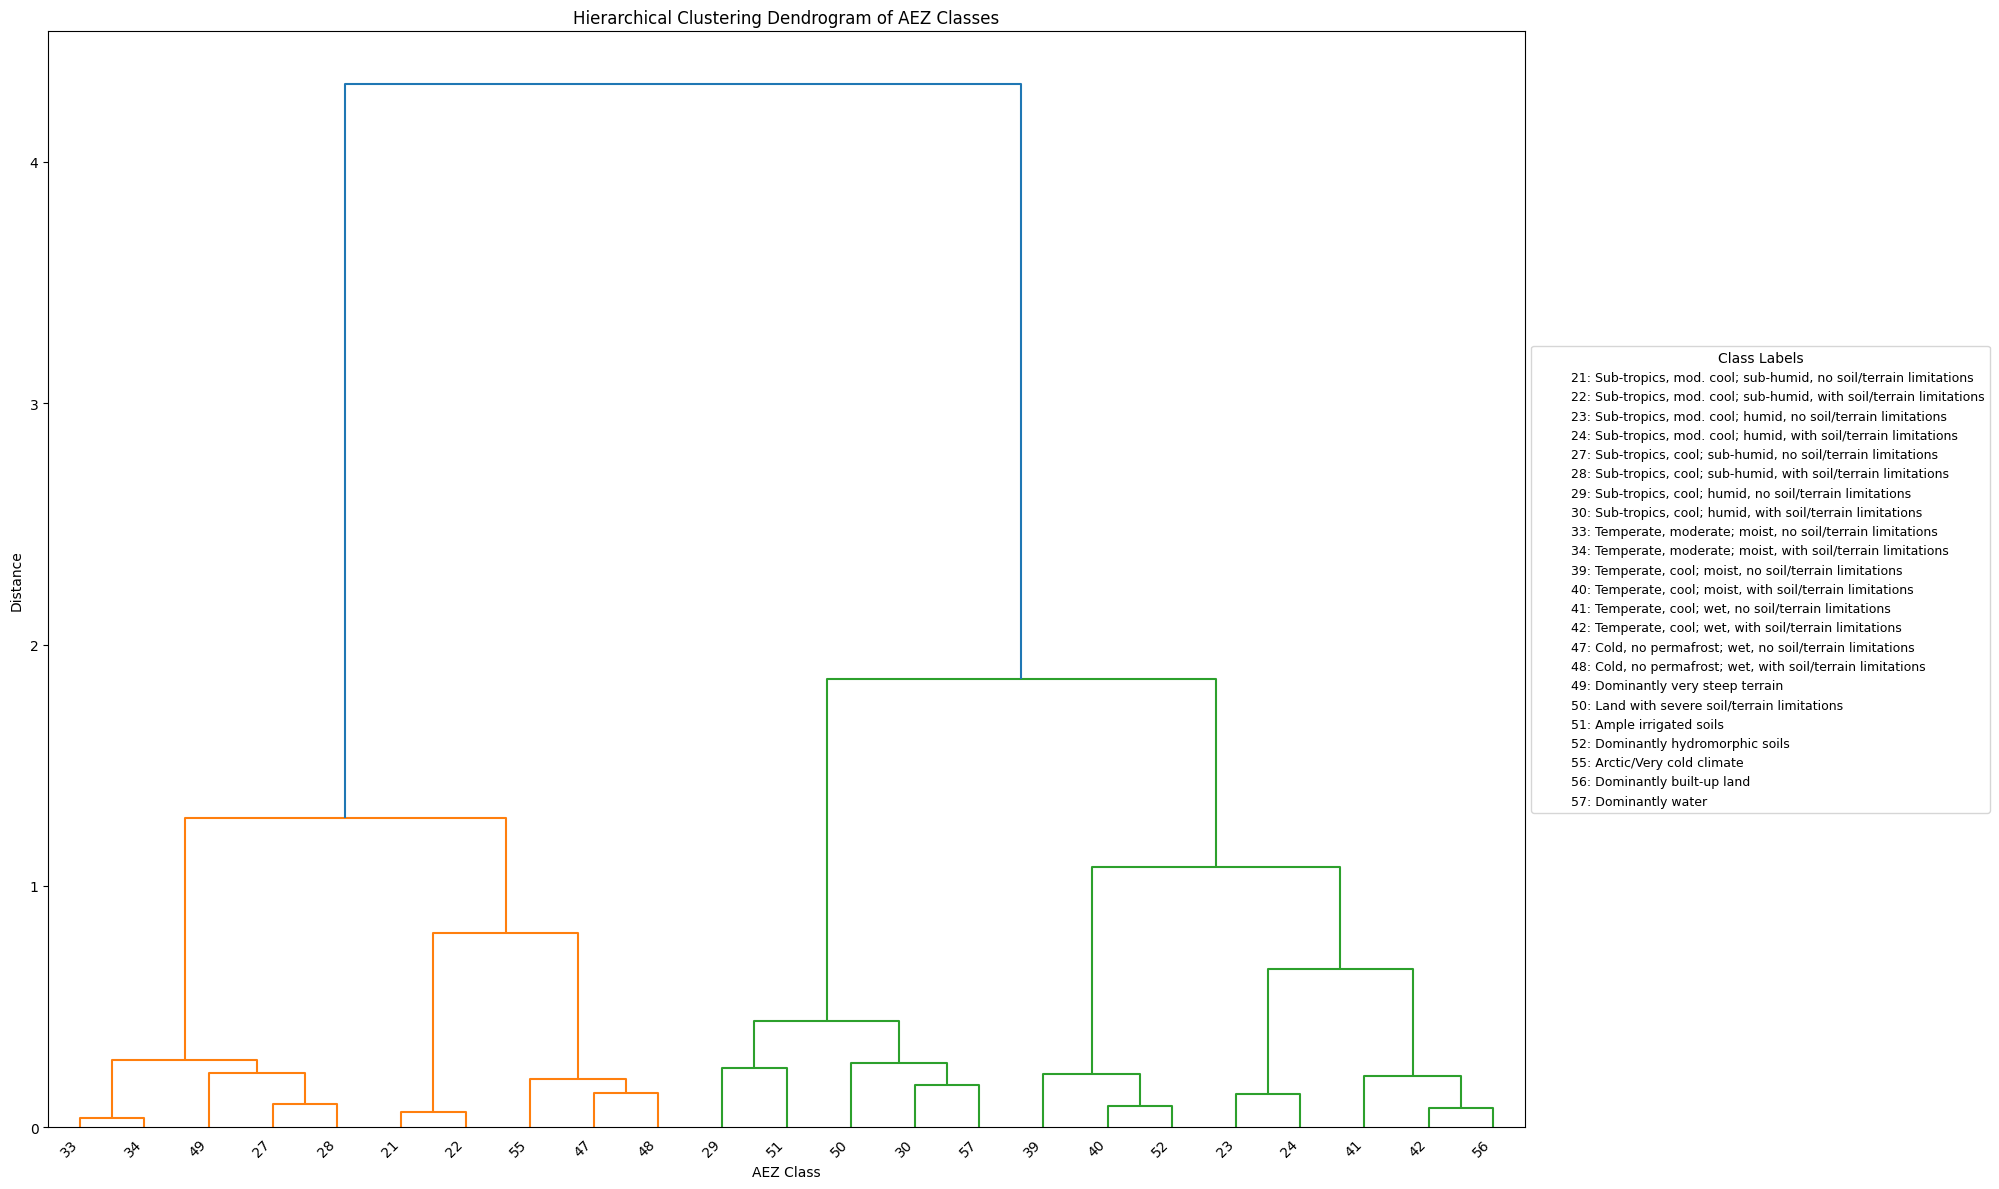

In [12]:
plot_dendrogram(sim_matrix, labels, aez_number_to_class_label)

In [13]:
def find_most_dissimilar_classes(sim_matrix, labels, n=5):
    triu_indices = np.triu_indices_from(sim_matrix, k=1)
    similarities = sim_matrix[triu_indices]
    
    most_dissimilar_idx = np.argsort(similarities)[:n]
    
    results = []
    for idx in most_dissimilar_idx:
        i, j = triu_indices[0][idx], triu_indices[1][idx]
        results.append((labels[i], labels[j], similarities[idx]))
    
    return results

find_most_dissimilar_classes(sim_matrix, [aez_number_to_class_label[lab] for lab in labels], n=10)

[('Temperate, cool; moist, no soil/terrain limitations',
  'Cold, no permafrost; wet, no soil/terrain limitations',
  np.float64(0.3328078607078793)),
 ('Sub-tropics, mod. cool; sub-humid, no soil/terrain limitations',
  'Temperate, cool; moist, no soil/terrain limitations',
  np.float64(0.36228692955205544)),
 ('Temperate, cool; moist, no soil/terrain limitations',
  'Cold, no permafrost; wet, with soil/terrain limitations',
  np.float64(0.368025466793478)),
 ('Cold, no permafrost; wet, no soil/terrain limitations',
  'Dominantly hydromorphic soils',
  np.float64(0.37146021617297703)),
 ('Sub-tropics, mod. cool; sub-humid, with soil/terrain limitations',
  'Temperate, cool; moist, no soil/terrain limitations',
  np.float64(0.37730395821598417)),
 ('Temperate, cool; moist, with soil/terrain limitations',
  'Cold, no permafrost; wet, no soil/terrain limitations',
  np.float64(0.3883363249645466)),
 ('Temperate, cool; moist, no soil/terrain limitations',
  'Arctic/Very cold climate',
  n

In [14]:
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from itertools import combinations
import time

def greedy_partition(centroids):
    """
    Greedy algorithm: Start with most dissimilar pair, then assign 
    remaining centroids to minimize inter-group similarity.
    """
    n = len(centroids)
    
    sim_matrix = cosine_similarity(centroids)
    
    min_sim = float('inf')
    start_pair = (0, 1)
    for i in range(n):
        for j in range(i+1, n):
            if sim_matrix[i, j] < min_sim:
                min_sim = sim_matrix[i, j]
                start_pair = (i, j)
    
    group1 = [start_pair[0]]
    group2 = [start_pair[1]]
    remaining = set(range(n)) - {start_pair[0], start_pair[1]}
    
    for idx in remaining:
        sim_to_g1 = np.mean([sim_matrix[idx, g] for g in group1])
        sim_to_g2 = np.mean([sim_matrix[idx, g] for g in group2])
        
        if sim_to_g1 < sim_to_g2:
            group1.append(idx)
        else:
            group2.append(idx)
    
    return group1, group2

def compute_inter_group_similarity(centroids, group1, group2):
    """Compute average cosine similarity between two groups."""
    if len(group1) == 0 or len(group2) == 0:
        return 0.0
    
    g1_centroids = centroids[group1]
    g2_centroids = centroids[group2]
    
    # Compute similarity between all pairs across groups
    cross_sim = cosine_similarity(g1_centroids, g2_centroids)
    return np.mean(cross_sim)

def kmeans_style_partition(centroids, max_iters=50):
    """
    K-means style: Iteratively update group assignments and representatives.
    """
    n = len(centroids)
    
    # Initialize with greedy partition
    group1, group2 = greedy_partition(centroids)
    
    for iteration in range(max_iters):
        # Compute group centers
        center1 = np.mean(centroids[group1], axis=0)
        center2 = np.mean(centroids[group2], axis=0)
        
        # Reassign each centroid to the farther center
        new_group1, new_group2 = [], []
        for i in range(n):
            sim1 = np.dot(centroids[i], center1) / (np.linalg.norm(centroids[i]) * np.linalg.norm(center1))
            sim2 = np.dot(centroids[i], center2) / (np.linalg.norm(centroids[i]) * np.linalg.norm(center2))
            
            if sim1 < sim2:  # Assign to farther (less similar) center
                new_group1.append(i)
            else:
                new_group2.append(i)
        
        # Check for convergence
        if set(new_group1) == set(group1):
            break
            
        group1, group2 = new_group1, new_group2
    
    return group1, group2

def simulated_annealing_partition(centroids, initial_temp=1.0, cooling_rate=0.95, max_iters=1000):
    """
    Simulated annealing to find partition with minimum inter-group similarity.
    """
    n = len(centroids)
    
    # Start with greedy partition
    current_partition = set(greedy_partition(centroids)[0])
    current_sim = compute_inter_group_similarity(
        centroids, 
        list(current_partition), 
        list(set(range(n)) - current_partition)
    )
    
    best_partition = current_partition.copy()
    best_sim = current_sim
    
    temp = initial_temp
    
    for iteration in range(max_iters):
        # Random neighbor: flip one centroid between groups
        neighbor = current_partition.copy()
        flip_idx = np.random.randint(n)
        
        if flip_idx in neighbor:
            neighbor.remove(flip_idx)
        else:
            neighbor.add(flip_idx)
        
        # Don't allow empty groups
        if len(neighbor) == 0 or len(neighbor) == n:
            continue
        
        neighbor_sim = compute_inter_group_similarity(
            centroids,
            list(neighbor),
            list(set(range(n)) - neighbor)
        )
        
        # Accept if better, or with probability based on temperature
        delta = neighbor_sim - current_sim
        if delta < 0 or np.random.random() < np.exp(-delta / temp):
            current_partition = neighbor
            current_sim = neighbor_sim
            
            if current_sim < best_sim:
                best_partition = current_partition.copy()
                best_sim = current_sim
        
        temp *= cooling_rate
    
    group1 = list(best_partition)
    group2 = list(set(range(n)) - best_partition)
    return group1, group2

# Example usage
if __name__ == "__main__":
    # Load your centroids here
    # centroids = np.load('your_centroids.npy')  # Shape: (57, 256)
    
    # For demonstration, create random centroids
    np.random.seed(42)
    centroids = np.random.randn(57, 256)
    # Normalize them (common for centroids)
    centroids = centroids / np.linalg.norm(centroids, axis=1, keepdims=True)
    
    print("Testing different partitioning algorithms...\n")
    
    # Method 1: Greedy
    print("1. Greedy Algorithm:")
    start = time.time()
    g1_greedy, g2_greedy = greedy_partition(centroids)
    sim_greedy = compute_inter_group_similarity(centroids, g1_greedy, g2_greedy)
    print(f"   Time: {time.time() - start:.4f}s")
    print(f"   Group sizes: {len(g1_greedy)}, {len(g2_greedy)}")
    print(f"   Inter-group similarity: {sim_greedy:.6f}\n")
    
    # Method 2: K-means style
    print("2. K-means Style Algorithm:")
    start = time.time()
    g1_kmeans, g2_kmeans = kmeans_style_partition(centroids)
    sim_kmeans = compute_inter_group_similarity(centroids, g1_kmeans, g2_kmeans)
    print(f"   Time: {time.time() - start:.4f}s")
    print(f"   Group sizes: {len(g1_kmeans)}, {len(g2_kmeans)}")
    print(f"   Inter-group similarity: {sim_kmeans:.6f}\n")
    
    # Method 3: Simulated Annealing
    print("3. Simulated Annealing:")
    start = time.time()
    g1_sa, g2_sa = simulated_annealing_partition(centroids, max_iters=2000)
    sim_sa = compute_inter_group_similarity(centroids, g1_sa, g2_sa)
    print(f"   Time: {time.time() - start:.4f}s")
    print(f"   Group sizes: {len(g1_sa)}, {len(g2_sa)}")
    print(f"   Inter-group similarity: {sim_sa:.6f}\n")
    
    # Pick the best result
    best_method = min(
        [("Greedy", sim_greedy, g1_greedy, g2_greedy),
         ("K-means", sim_kmeans, g1_kmeans, g2_kmeans),
         ("Simulated Annealing", sim_sa, g1_sa, g2_sa)],
        key=lambda x: x[1]
    )
    
    print(f"Best method: {best_method[0]}")
    print(f"Final inter-group similarity: {best_method[1]:.6f}")
    print(f"\nGroup 1 indices: {sorted(best_method[2])}")
    print(f"Group 2 indices: {sorted(best_method[3])}")

Testing different partitioning algorithms...

1. Greedy Algorithm:
   Time: 0.0010s
   Group sizes: 31, 26
   Inter-group similarity: 0.009052

2. K-means Style Algorithm:
   Time: 0.0145s
   Group sizes: 31, 26
   Inter-group similarity: 0.006042

3. Simulated Annealing:
   Time: 0.3144s
   Group sizes: 20, 37
   Inter-group similarity: -0.009850

Best method: Simulated Annealing
Final inter-group similarity: -0.009850

Group 1 indices: [3, 6, 8, 9, 10, 11, 13, 23, 24, 25, 27, 30, 32, 44, 48, 49, 50, 51, 52, 55]
Group 2 indices: [0, 1, 2, 4, 5, 7, 12, 14, 15, 16, 17, 18, 19, 20, 21, 22, 26, 28, 29, 31, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 45, 46, 47, 53, 54, 56]


In [15]:
def plot_train_test_similarity(centroids, 
                               train_indices, 
                               test_indices, 
                               aez_number_to_class_label):
    sim_matrix = cosine_similarity(centroids)
    
    
    ordered_indices = list(train_indices) + list(test_indices)
    ordered_sim_matrix = sim_matrix[np.ix_(ordered_indices, ordered_indices)]
    ordered_labels = [i for i in range(len(centroids))]
    
    fig, ax = plt.subplots(figsize=(12, 10))
    sns.heatmap(ordered_sim_matrix, 
                xticklabels=ordered_labels,
                yticklabels=ordered_labels,
                cmap='RdYlBu_r',
                center=0.5,
                annot=True,
                fmt='.2f',
                square=True,
                cbar_kws={'label': 'Cosine Similarity'},
                ax=ax)
    
    legend_elements = [Patch(facecolor='none', edgecolor='none', 
                            label=f'{label}: {aez_number_to_class_label[label]}') 
                      for label in ordered_labels]
    
    fig.legend(handles=legend_elements, title='Class Labels', 
              bbox_to_anchor=(0.85, 0.5), loc='center left', 
              frameon=True, fontsize=9)

    n_train = len(train_indices)
    ax.axhline(y=n_train, color='black', linewidth=3)
    ax.axvline(x=n_train, color='black', linewidth=3)
    
    ax.text(n_train/2, -0.5, 'TRAIN', ha='center', fontsize=14, fontweight='bold')
    ax.text(n_train + len(test_indices)/2, -0.5, 'TEST', ha='center', fontsize=14, fontweight='bold')
    ax.text(-0.5, n_train/2, 'TRAIN', va='center', fontsize=14, fontweight='bold', rotation=90)
    ax.text(-0.5, n_train + len(test_indices)/2, 'TEST', va='center', fontsize=14, fontweight='bold', rotation=90)
    
    plt.title('Train-Test Similarity Matrix')
    plt.tight_layout()
    
    train_train_sim = ordered_sim_matrix[:n_train, :n_train]
    test_test_sim = ordered_sim_matrix[n_train:, n_train:]
    train_test_sim = ordered_sim_matrix[:n_train, n_train:]
    
    print(f"\nSimilarity Statistics:")
    print(f"Train-Train (within): {np.mean(train_train_sim[np.triu_indices_from(train_train_sim, k=1)]):.3f}")
    print(f"Test-Test (within): {np.mean(test_test_sim[np.triu_indices_from(test_test_sim, k=1)]):.3f}")
    print(f"Train-Test (between): {np.mean(train_test_sim):.3f}")
    print(f"Separation ratio: {np.mean(train_test_sim) / np.mean(train_train_sim):.3f} (lower is better)")
    
    return fig


def check_train_test_indices(train_indices, 
                             test_indices, 
                             gdf, 
                             centroids,
                             labels,
                             aez_number_to_class_label):
    gdf["aez_class"] = gdf["aez_class"].astype(str)
    def check_indices(indices, gdf, aez_number_to_class_label):
        gdf_len = len(gdf)
        labs = [aez_number_to_class_label[i] for i in indices]
        labs_len = len(gdf[gdf["aez_class"].isin(labs)])
        for i in indices:
            lab = aez_number_to_class_label[i]
            lab_len = len(gdf[gdf["aez_class"] == lab])
            print(f"{lab}:{lab_len} samples({100 * (lab_len / gdf_len):.3f}% of total GDF)")
        print(f"TOTAL OF GDF:{100 * (labs_len / gdf_len):.3f}%")
    print("TRAIN INDICES:")
    check_indices(train_indices, gdf, aez_number_to_class_label)
    print("TEST INDICES:")
    check_indices(test_indices, gdf, aez_number_to_class_label)

    train_test_labs = [(1 if i in train_indices else 0) for i in np.unique(labels)]
    group_centroids, group_labels = get_class_centroids(centroids, torch.tensor(train_test_labs))
    group_sim_matrix = cosine_similarity(group_centroids)
    plot_similarity_matrix(group_sim_matrix, group_labels, {0:"test", 1:"train"})

    inner_train_indices = [i for i,j in enumerate(labels) if j in train_indices]
    inner_test_indices = [i for i,j in enumerate(labels) if i in test_indices]
    inner_aez_number_to_class_label = {i:aez_number_to_class_label[j] for i,j in enumerate(labels)}
    #plot_train_test_similarity(centroids, inner_train_indices, inner_test_indices, inner_aez_number_to_class_label)

In [18]:
g1_sa, g2_sa = simulated_annealing_partition(centroids, max_iters=2000)
len(g1_sa)

31

In [17]:
check_train_test_indices(g1_sa, 
                         g2_sa, 
                         gdf, 
                         centroids, 
                         labels,
                         aez_number_to_class_label)
                         

TRAIN INDICES:
Unclassified:35153 samples(5.820% of total GDF)
Tropics, lowland; semi-arid, with soil/terrain limitations:0 samples(0.000% of total GDF)
Tropics, lowland; sub-humid, with soil/terrain limitations:0 samples(0.000% of total GDF)
Tropics, lowland; humid, with soil/terrain limitations:0 samples(0.000% of total GDF)
Tropics, highland; semi-arid, no soil/terrain limitations:0 samples(0.000% of total GDF)
Tropics, highland; humid, with soil/terrain limitations:0 samples(0.000% of total GDF)
Sub-tropics, warm; semi-arid, with soil/terrain limitations:0 samples(0.000% of total GDF)
Sub-tropics, warm; sub-humid, no soil/terrain limitations:0 samples(0.000% of total GDF)
Sub-tropics, warm; humid, no soil/terrain limitations:0 samples(0.000% of total GDF)
Sub-tropics, warm; humid, with soil/terrain limitations:0 samples(0.000% of total GDF)
Sub-tropics, mod. cool; semi-arid, no soil/terrain limitations:0 samples(0.000% of total GDF)
Sub-tropics, mod. cool; sub-humid, no soil/terrai

/tmp/ipykernel_472297/2048871702.py:2: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  unique_labels = np.array(torch.unique(y))


IndexError: boolean index did not match indexed array along axis 0; size of axis is 57 but size of corresponding boolean axis is 23

In [ ]:
train_test_index_dict = {
    
}

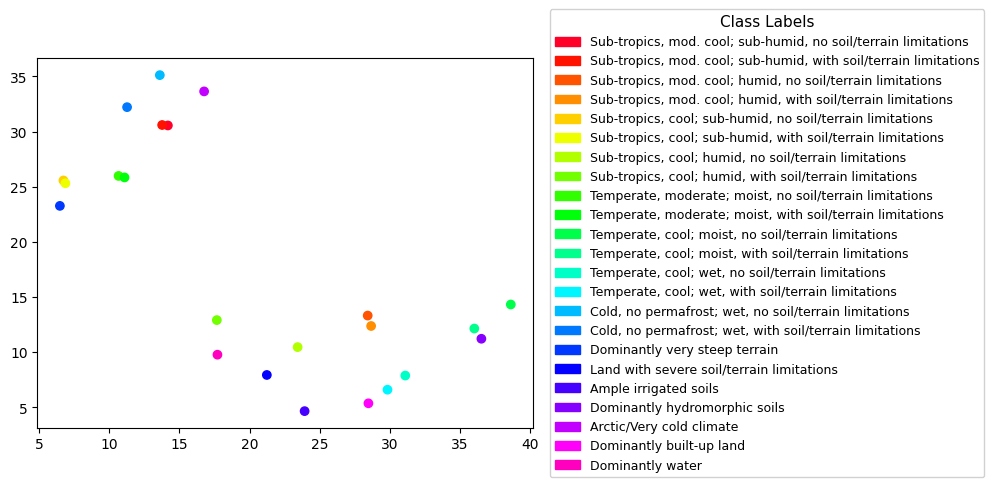

In [ ]:

kmeans = KMeans(n_clusters=2)

centroids_transformed = kmeans.fit_transform(centroids, labels)
colors = plt.cm.gist_rainbow(np.linspace(0, 1, len(labels)))
legend_labels = [aez_number_to_class_label[lab] for lab in labels]
handles = [mpatches.Patch(color=c, label=lab) for c,lab in zip(colors,[aez_number_to_class_label[lab] for lab in labels])]


plt.legend(handles=handles,
        loc='center left', 
        bbox_to_anchor=(1.02, 0.5),
        fontsize=9,
        framealpha=0.9,
        title='Class Labels',
        title_fontsize=11)

plt.scatter([p[0] for p in centroids_transformed], [p[1] for p in centroids_transformed], c=colors)

TRAIN INDICES:
Sub-tropics, mod. cool; sub-humid, no soil/terrain limitations:5072 samples(0.840% of total GDF)
Sub-tropics, mod. cool; sub-humid, with soil/terrain limitations:6908 samples(1.144% of total GDF)
Sub-tropics, cool; sub-humid, no soil/terrain limitations:4639 samples(0.768% of total GDF)
Sub-tropics, cool; sub-humid, with soil/terrain limitations:15116 samples(2.503% of total GDF)
Temperate, moderate; moist, no soil/terrain limitations:191 samples(0.032% of total GDF)
Temperate, moderate; moist, with soil/terrain limitations:347 samples(0.057% of total GDF)
Cold, no permafrost; wet, no soil/terrain limitations:4 samples(0.001% of total GDF)
Cold, no permafrost; wet, with soil/terrain limitations:278 samples(0.046% of total GDF)
Dominantly very steep terrain:10170 samples(1.684% of total GDF)
Arctic/Very cold climate:12 samples(0.002% of total GDF)
TOTAL OF GDF:7.076%
TEST INDICES:
Sub-tropics, mod. cool; humid, no soil/terrain limitations:9878 samples(1.635% of total GDF)

/tmp/ipykernel_123579/2048871702.py:2: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  unique_labels = np.array(torch.unique(y))


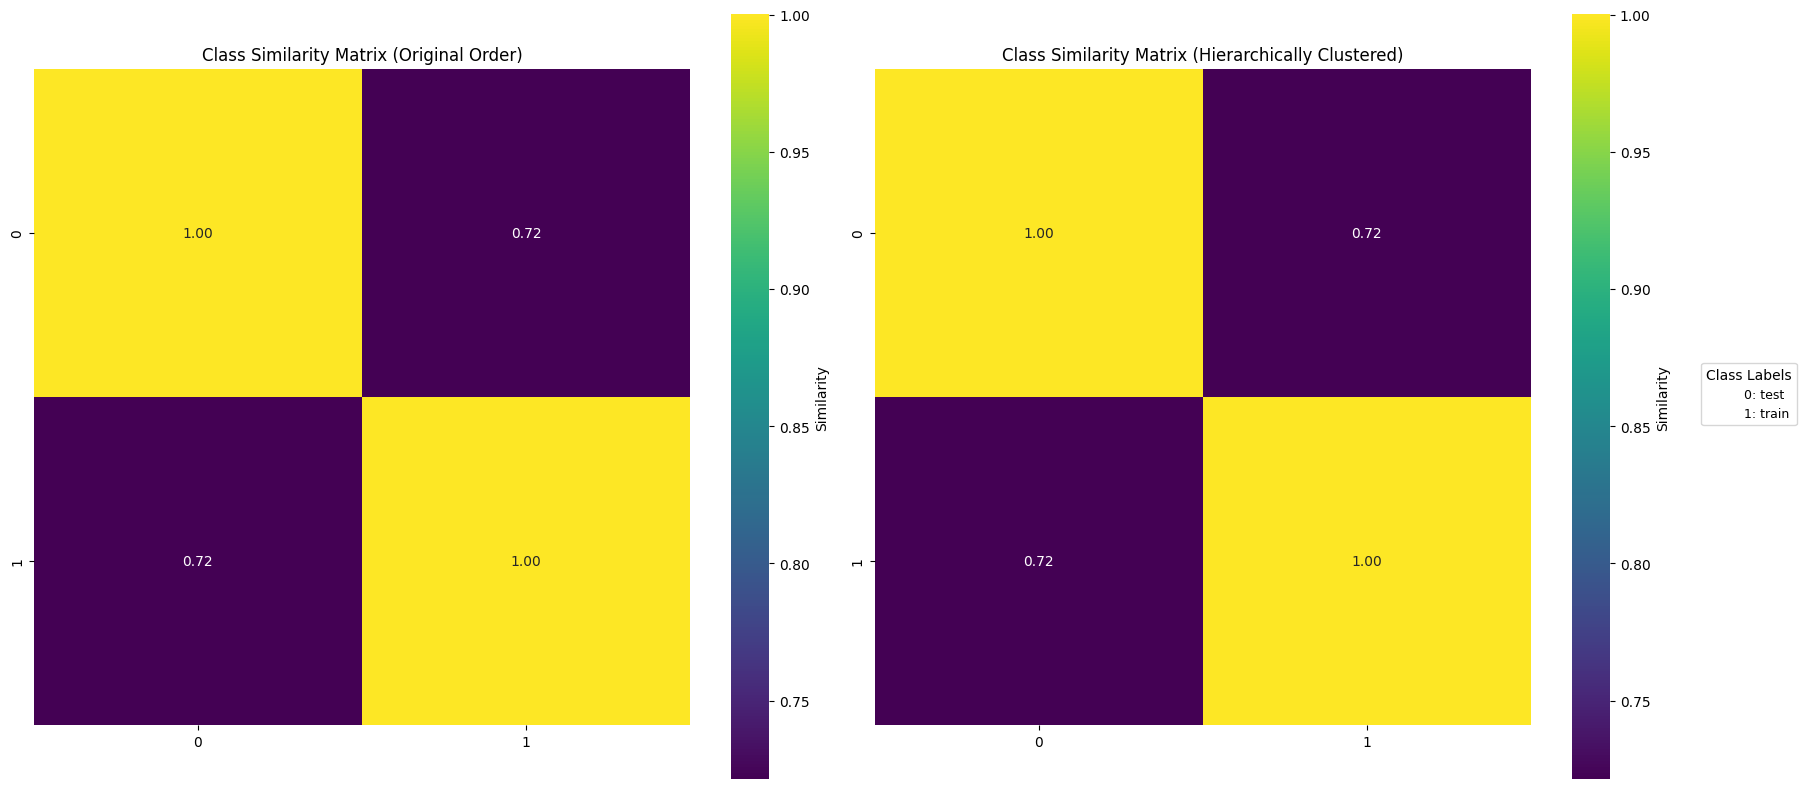

In [ ]:
preds = kmeans.predict(centroids)

check_train_test_indices([l for i,l in enumerate(labels) if preds[i] == 0], 
                         [l for i,l in enumerate(labels) if preds[i] == 1], 
                         gdf, 
                         centroids, 
                         labels,
                         aez_number_to_class_label)


In [ ]:
labels[~preds]

array([57, 57, 56, 56, 57, 57, 56, 56, 57, 57, 56, 56, 56, 56, 57, 57, 57,
       56, 56, 56, 57, 56, 56])

TRAIN INDICES:
Sub-tropics, mod. cool; sub-humid, no soil/terrain limitations:5072 samples(0.840% of total GDF)


Sub-tropics, mod. cool; sub-humid, with soil/terrain limitations:6908 samples(1.144% of total GDF)
Sub-tropics, cool; sub-humid, no soil/terrain limitations:4639 samples(0.768% of total GDF)
Sub-tropics, cool; sub-humid, with soil/terrain limitations:15116 samples(2.503% of total GDF)
TOTAL OF GDF:5.254%
TEST INDICES:
Sub-tropics, mod. cool; humid, no soil/terrain limitations:9878 samples(1.635% of total GDF)
Sub-tropics, mod. cool; humid, with soil/terrain limitations:8764 samples(1.451% of total GDF)
Sub-tropics, cool; humid, no soil/terrain limitations:25142 samples(4.163% of total GDF)
Sub-tropics, cool; humid, with soil/terrain limitations:23801 samples(3.941% of total GDF)
Temperate, moderate; moist, no soil/terrain limitations:191 samples(0.032% of total GDF)
Temperate, moderate; moist, with soil/terrain limitations:347 samples(0.057% of total GDF)
Temperate, cool; moist, no soil/terrain limitations:96352 samples(15.952% of total GDF)
Temperate, cool; moist, with soil/terrain li

/tmp/ipykernel_123579/2048871702.py:2: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  unique_labels = np.array(torch.unique(y))


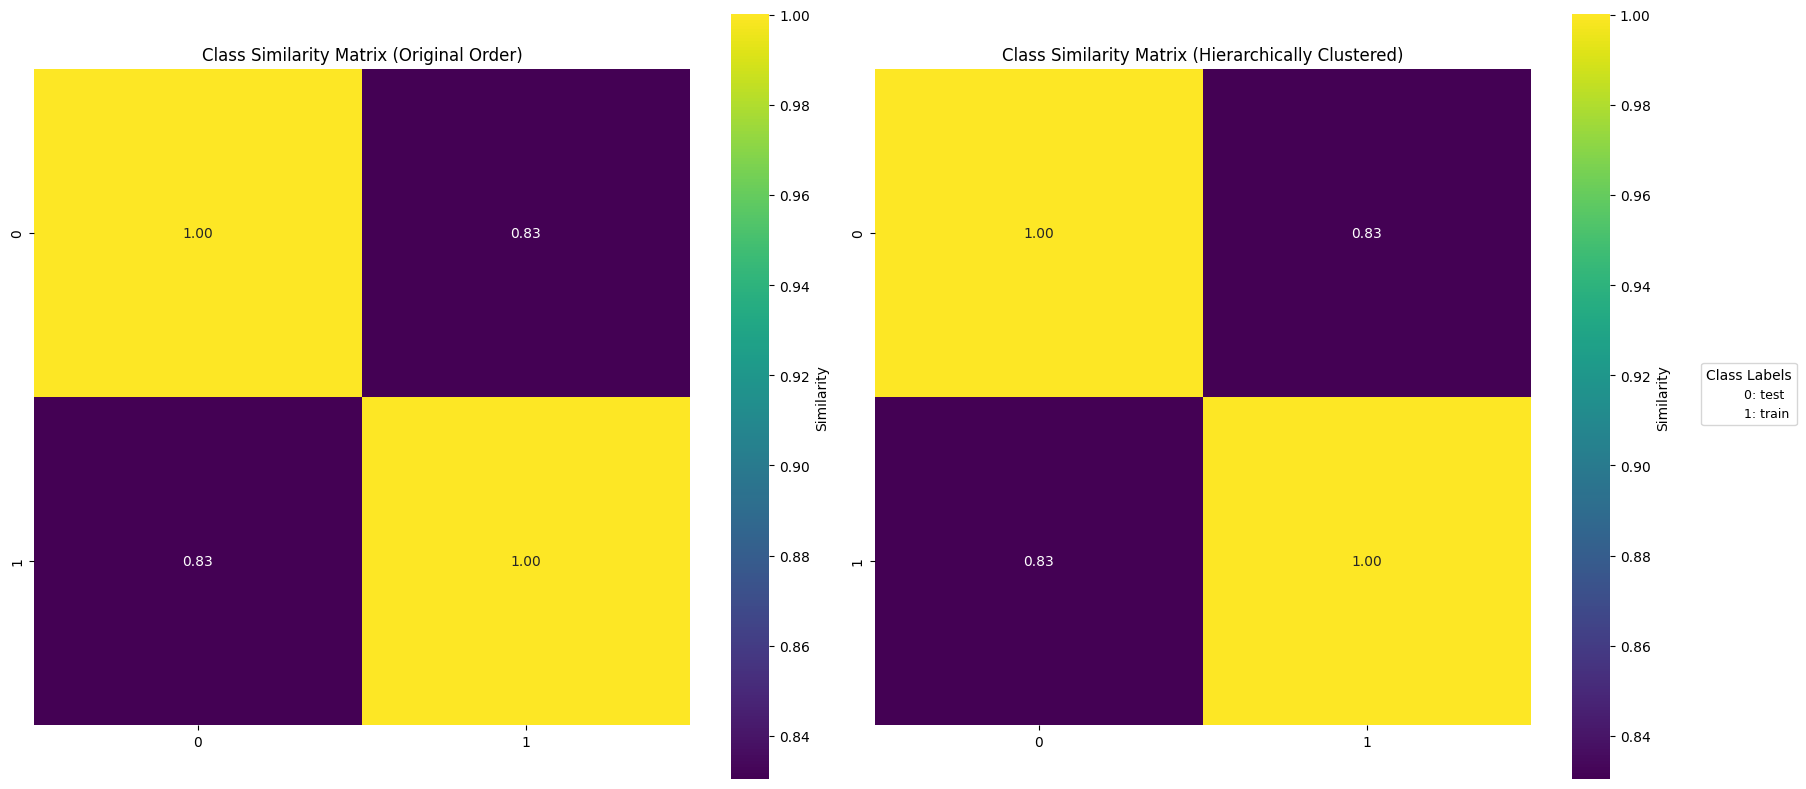

In [ ]:
from sklearn.cluster import SpectralClustering

def perform_spectral_clustering(centroids, labels, n_clusters=5):
    dist_matrix = 1 - cosine_similarity(centroids)

    clustering = SpectralClustering(n_clusters=n_clusters, affinity='precomputed')
    cluster_labels = clustering.fit_predict(1 - dist_matrix)

    

    return cluster_labels

spectral_preds = perform_spectral_clustering(centroids, labels)

check_train_test_indices([l for i,l in enumerate(labels) if spectral_preds[i] == 4], 
                         [l for i,l in enumerate(labels) if spectral_preds[i] != 4], 
                         gdf, 
                         centroids, 
                         labels,
                         aez_number_to_class_label)



In [ ]:
from collections import defaultdict
preds = kmeans.predict(centroids)
groups = defaultdict(list)

for pred, lab in zip(preds, text_labels):
    groups[pred] += [lab]

for k in groups:
    print(f"GROUP {k}:")
    members = groups[k]
    for m in members:
        print(m)

GROUP 0:
Sub-tropics, mod. cool; sub-humid, no soil/terrain limitations
Sub-tropics, mod. cool; sub-humid, with soil/terrain limitations
Sub-tropics, cool; sub-humid, no soil/terrain limitations
Sub-tropics, cool; sub-humid, with soil/terrain limitations
Temperate, moderate; moist, no soil/terrain limitations
Temperate, moderate; moist, with soil/terrain limitations
Cold, no permafrost; wet, no soil/terrain limitations
Cold, no permafrost; wet, with soil/terrain limitations
Dominantly very steep terrain
Arctic/Very cold climate
GROUP 1:
Sub-tropics, mod. cool; humid, no soil/terrain limitations
Sub-tropics, mod. cool; humid, with soil/terrain limitations
Sub-tropics, cool; humid, no soil/terrain limitations
Sub-tropics, cool; humid, with soil/terrain limitations
Temperate, cool; moist, no soil/terrain limitations
Temperate, cool; moist, with soil/terrain limitations
Temperate, cool; wet, no soil/terrain limitations
Temperate, cool; wet, with soil/terrain limitations
Land with severe so

TRAIN INDICES:


Sub-tropics, mod. cool; sub-humid, no soil/terrain limitations:5072 samples(0.840% of total GDF)
Sub-tropics, mod. cool; sub-humid, with soil/terrain limitations:6908 samples(1.144% of total GDF)
Sub-tropics, mod. cool; humid, no soil/terrain limitations:9878 samples(1.635% of total GDF)
Sub-tropics, mod. cool; humid, with soil/terrain limitations:8764 samples(1.451% of total GDF)
Sub-tropics, cool; sub-humid, no soil/terrain limitations:4639 samples(0.768% of total GDF)
Sub-tropics, cool; sub-humid, with soil/terrain limitations:15116 samples(2.503% of total GDF)
Sub-tropics, cool; humid, no soil/terrain limitations:25142 samples(4.163% of total GDF)
Sub-tropics, cool; humid, with soil/terrain limitations:23801 samples(3.941% of total GDF)
Temperate, moderate; moist, no soil/terrain limitations:191 samples(0.032% of total GDF)
Temperate, moderate; moist, with soil/terrain limitations:347 samples(0.057% of total GDF)
Temperate, cool; moist, with soil/terrain limitations:75979 samples(1

/tmp/ipykernel_123579/2048871702.py:2: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  unique_labels = np.array(torch.unique(y))


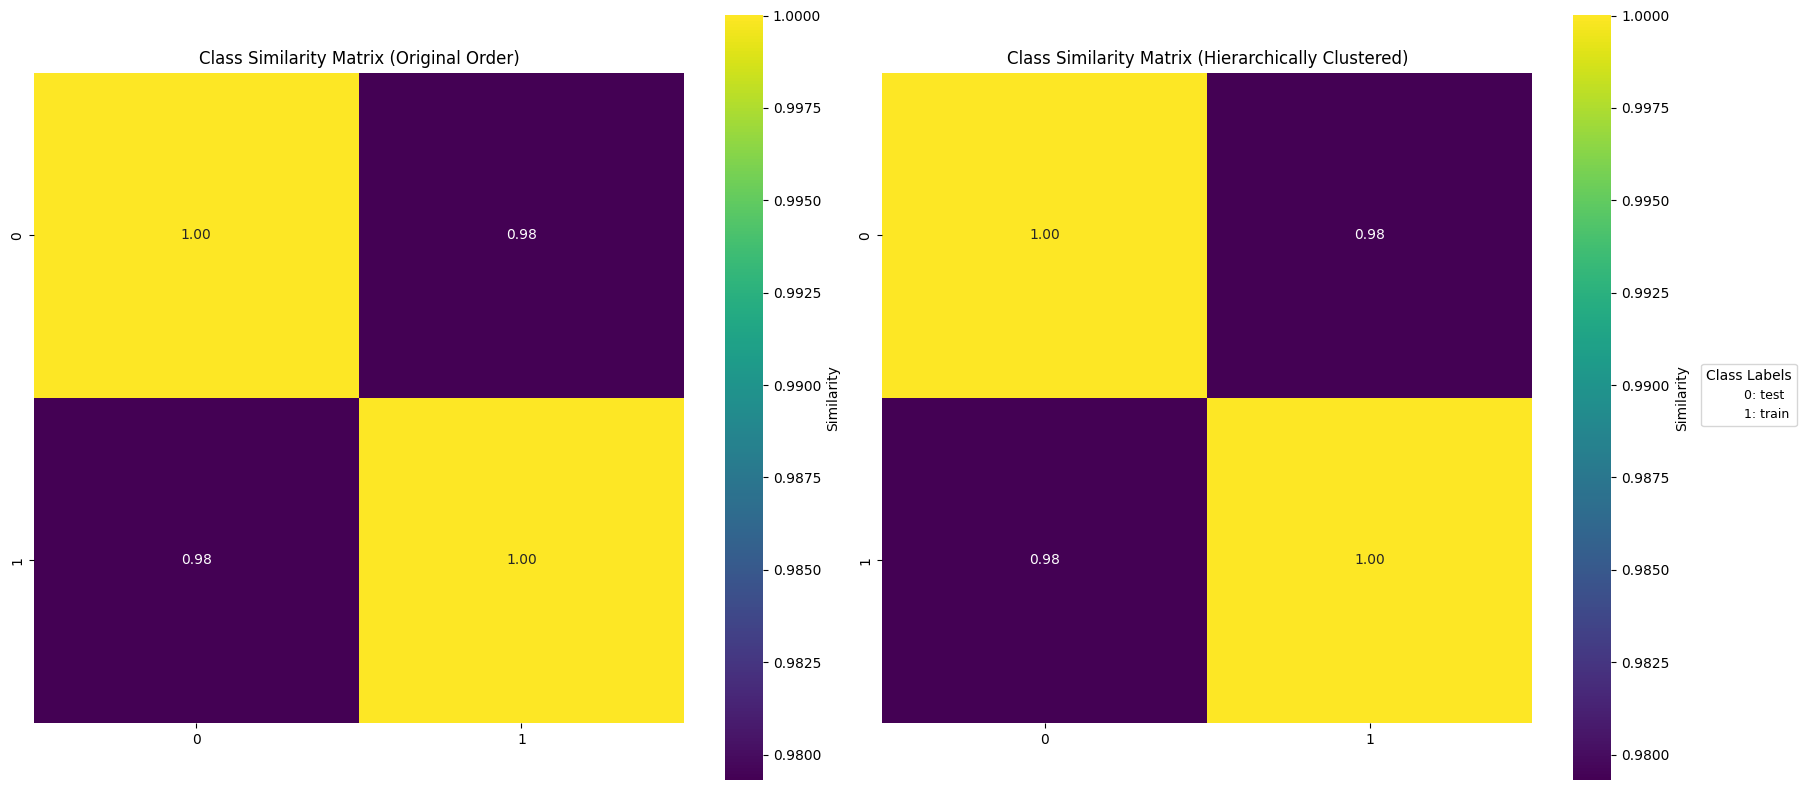

In [ ]:
def greedy_distant_split(centroids, labels, test_ratio=0.2, minimize_avg=True):
    from sklearn.metrics.pairwise import cosine_similarity
    
    n_classes = len(labels)
    n_test = max(1, int(n_classes * test_ratio))
    
    sim_matrix = cosine_similarity(centroids)
    
    mean_similarities = sim_matrix.sum(axis=1) / (n_classes - 1)
    least_similar = mean_similarities.argmin()
    
    test_indices = {least_similar}
    train_indices = set(range(n_classes)) - test_indices
    
    while len(test_indices) < n_test:
        best_idx = None
        best_sim = float('inf')
        
        for idx in train_indices:
            remaining_train = train_indices - {idx}
            if len(remaining_train) == 0:
                current_sim = 1.0
            else:
                if minimize_avg:
                    current_sim = np.mean([sim_matrix[idx, t] for t in remaining_train])
                    if current_sim < best_sim:
                        best_sim = current_sim
                        best_idx = idx
                else:
                    current_sim = max(sim_matrix[idx, t] for t in remaining_train)
            if current_sim < best_sim:
                best_sim = current_sim
                best_idx = idx

            
        
        test_indices.add(best_idx)
        train_indices.remove(best_idx)
  
    
    return [labels[i] for i in train_indices], [labels[i] for i in test_indices]

train_indices, test_indices = greedy_distant_split(centroids, labels, minimize_avg=False)
check_train_test_indices(train_indices, test_indices, gdf, centroids, labels, aez_number_to_class_label)


In [ ]:
import numpy as np
from scipy.optimize import differential_evolution, minimize
from sklearn.metrics.pairwise import euclidean_distances, cosine_distances
import warnings

def optimization_split(centroids, test_size=0.2, method='evolutionary', 
                       distance_metric='euclidean', max_iter=1000, seed=None):
   
    if seed is not None:
        np.random.seed(seed)
    
    n_classes = len(centroids)
    
    if isinstance(test_size, float):
        n_test = int(n_classes * test_size)
    else:
        n_test = test_size
    n_train = n_classes - n_test
    
    if distance_metric == 'euclidean':
        distances = euclidean_distances(centroids)
    elif distance_metric == 'cosine':
        distances = cosine_distances(centroids)
    else:
        raise ValueError(f"Unknown distance metric: {distance_metric}")
    
    if method == 'evolutionary':
        return _evolutionary_split(distances, n_test, max_iter, seed)
    elif method == 'simulated_annealing':
        return _simulated_annealing_split(distances, n_test, max_iter, seed)
    else:
        raise ValueError(f"Unknown method: {method}")


def _evolutionary_split(distances, n_test, max_iter, seed):
    """Use differential evolution for global optimization."""
    n_classes = len(distances)
    
    def objective(x):
        """Objective: maximize mean distance between train and test."""
        # x is a continuous vector [0, 1]^n
        # Convert to binary: top n_test values become test set
        test_mask = x >= np.partition(x, -n_test)[-n_test]
        train_mask = ~test_mask
        
        if np.sum(test_mask) != n_test or np.sum(train_mask) != (n_classes - n_test):
            return 1e10  # Penalty for invalid split
        
        # Compute mean distance between train and test
        test_indices = np.where(test_mask)[0]
        train_indices = np.where(train_mask)[0]
        
        cross_distances = distances[np.ix_(train_indices, test_indices)]
        mean_dist = np.mean(cross_distances)
        
        # We want to maximize, but scipy minimizes, so return negative
        return -mean_dist
    
    # Bounds: each variable between 0 and 1
    bounds = [(0, 1) for _ in range(n_classes)]
    
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        result = differential_evolution(
            objective, 
            bounds, 
            maxiter=max_iter,
            seed=seed,
            polish=False,
            workers=1
        )
    
    # Extract final split
    x = result.x
    test_mask = x >= np.partition(x, -n_test)[-n_test]
    test_indices = np.where(test_mask)[0]
    train_indices = np.where(~test_mask)[0]
    
    objective_value = -result.fun
    
    return train_indices, test_indices, objective_value


def _simulated_annealing_split(distances, n_test, max_iter, seed):
    """Use simulated annealing-style optimization."""
    n_classes = len(distances)
    
    # Initialize with random split
    indices = np.arange(n_classes)
    if seed is not None:
        np.random.seed(seed)
    np.random.shuffle(indices)
    test_indices = indices[:n_test]
    train_indices = indices[n_test:]
    
    def compute_objective(train_idx, test_idx):
        """Compute mean distance between train and test."""
        cross_distances = distances[np.ix_(train_idx, test_idx)]
        return np.mean(cross_distances)
    
    current_obj = compute_objective(train_indices, test_indices)
    best_obj = current_obj
    best_train = train_indices.copy()
    best_test = test_indices.copy()
    
    temp = 1.0
    cooling_rate = 0.995
    
    for iteration in range(max_iter):
        train_swap_idx = np.random.randint(len(train_indices))
        test_swap_idx = np.random.randint(len(test_indices))
        
        new_train = train_indices.copy()
        new_test = test_indices.copy()
        new_train[train_swap_idx], new_test[test_swap_idx] = new_test[test_swap_idx], new_train[train_swap_idx]
        
        new_obj = compute_objective(new_train, new_test)
        
        delta = new_obj - current_obj
        if delta > 0 or np.random.random() < np.exp(delta / temp):
            train_indices = new_train
            test_indices = new_test
            current_obj = new_obj
            
            if current_obj > best_obj:
                best_obj = current_obj
                best_train = train_indices.copy()
                best_test = test_indices.copy()
        
        temp *= cooling_rate
    
    return best_train, best_test, best_obj



TRAIN INDICES:
Sub-tropics, mod. cool; sub-humid, with soil/terrain limitations:6908 samples(1.144% of total GDF)
Sub-tropics, mod. cool; humid, no soil/terrain limitations:9878 samples(1.635% of total GDF)
Sub-tropics, mod. cool; humid, with soil/terrain limitations:8764 samples(1.451% of total GDF)
Sub-tropics, cool; sub-humid, no soil/terrain limitations:4639 samples(0.768% of total GDF)
Sub-tropics, cool; sub-humid, with soil/terrain limitations:15116 samples(2.503% of total GDF)
Sub-tropics, cool; humid, no soil/terrain limitations:25142 samples(4.163% of total GDF)
Sub-tropics, cool; humid, with soil/terrain limitations:23801 samples(3.941% of total GDF)
Temperate, moderate; moist, no soil/terrain limitations:191 samples(0.032% of total GDF)
Temperate, moderate; moist, with soil/terrain limitations:347 samples(0.057% of total GDF)
Temperate, cool; moist, no soil/terrain limitations:96352 samples(15.952% of total GDF)
Temperate, cool; moist, with soil/terrain limitations:75979 sam

/tmp/ipykernel_123579/2048871702.py:2: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  unique_labels = np.array(torch.unique(y))


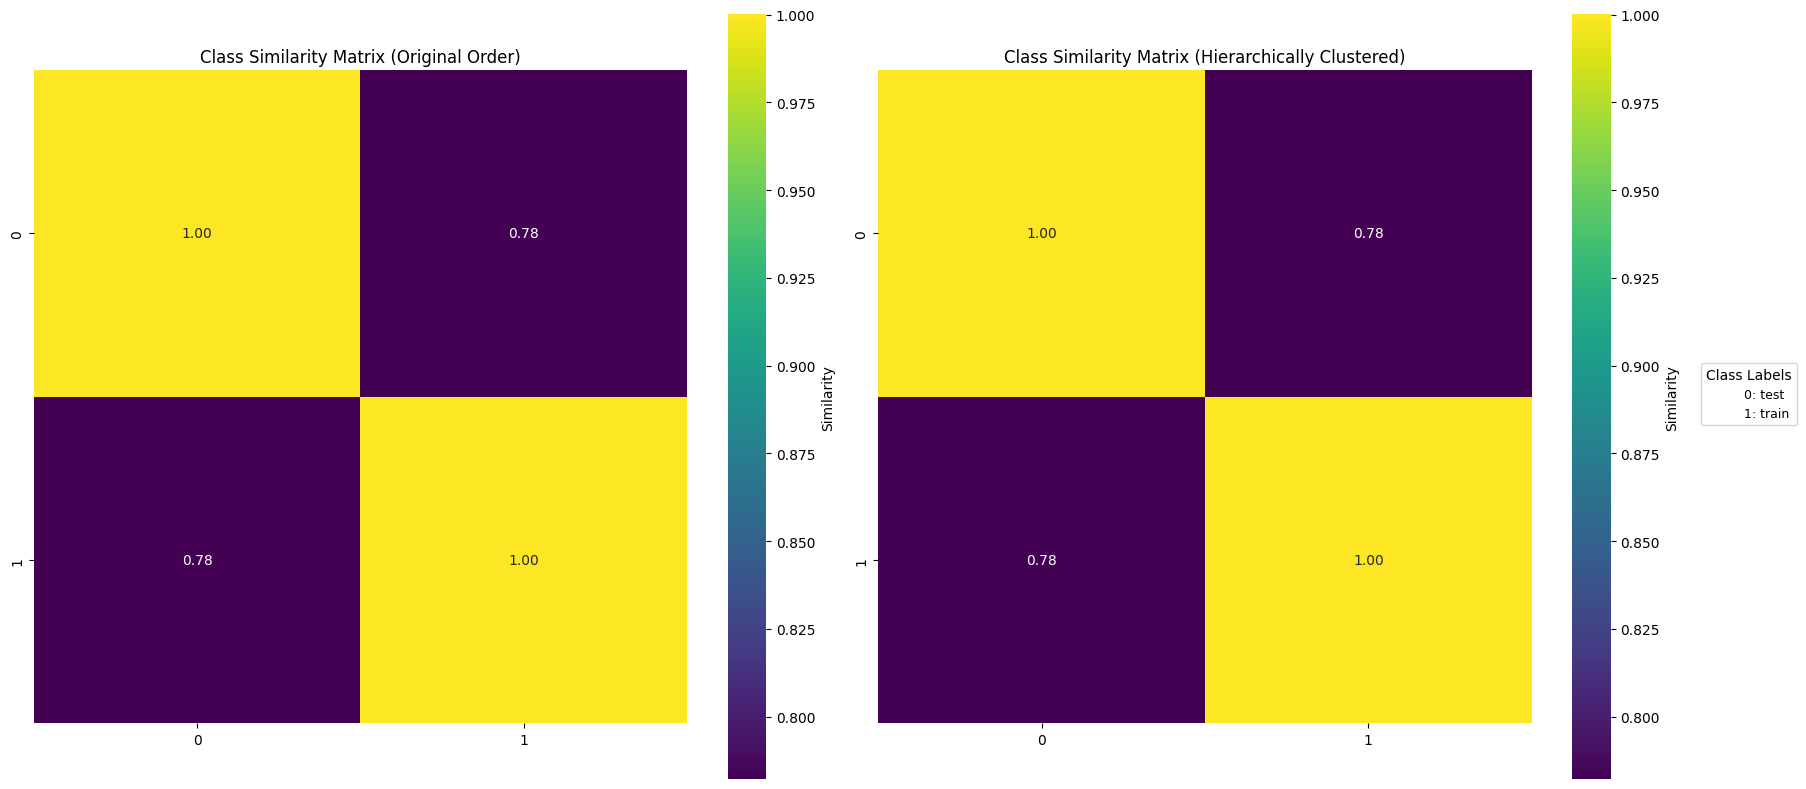

In [ ]:
train_idx, test_idx, obj_val = optimization_split(
    centroids, 
    test_size=0.2, 
    method='evolutionary',
    max_iter=100,
    seed=42
)

check_train_test_indices([l for i,l in enumerate(labels) if i in train_idx], 
                         [l for i,l in enumerate(labels) if i in test_idx], 
                         gdf, 
                         centroids, 
                         labels,
                         aez_number_to_class_label)


TRAIN INDICES:


Sub-tropics, mod. cool; sub-humid, no soil/terrain limitations:5072 samples(0.840% of total GDF)
Sub-tropics, mod. cool; humid, no soil/terrain limitations:9878 samples(1.635% of total GDF)
Sub-tropics, mod. cool; humid, with soil/terrain limitations:8764 samples(1.451% of total GDF)
Sub-tropics, cool; sub-humid, no soil/terrain limitations:4639 samples(0.768% of total GDF)
Sub-tropics, cool; sub-humid, with soil/terrain limitations:15116 samples(2.503% of total GDF)
Sub-tropics, cool; humid, no soil/terrain limitations:25142 samples(4.163% of total GDF)
Sub-tropics, cool; humid, with soil/terrain limitations:23801 samples(3.941% of total GDF)
Temperate, moderate; moist, no soil/terrain limitations:191 samples(0.032% of total GDF)
Temperate, moderate; moist, with soil/terrain limitations:347 samples(0.057% of total GDF)
Temperate, cool; moist, no soil/terrain limitations:96352 samples(15.952% of total GDF)
Temperate, cool; moist, with soil/terrain limitations:75979 samples(12.579% of t

/tmp/ipykernel_123579/2048871702.py:2: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  unique_labels = np.array(torch.unique(y))


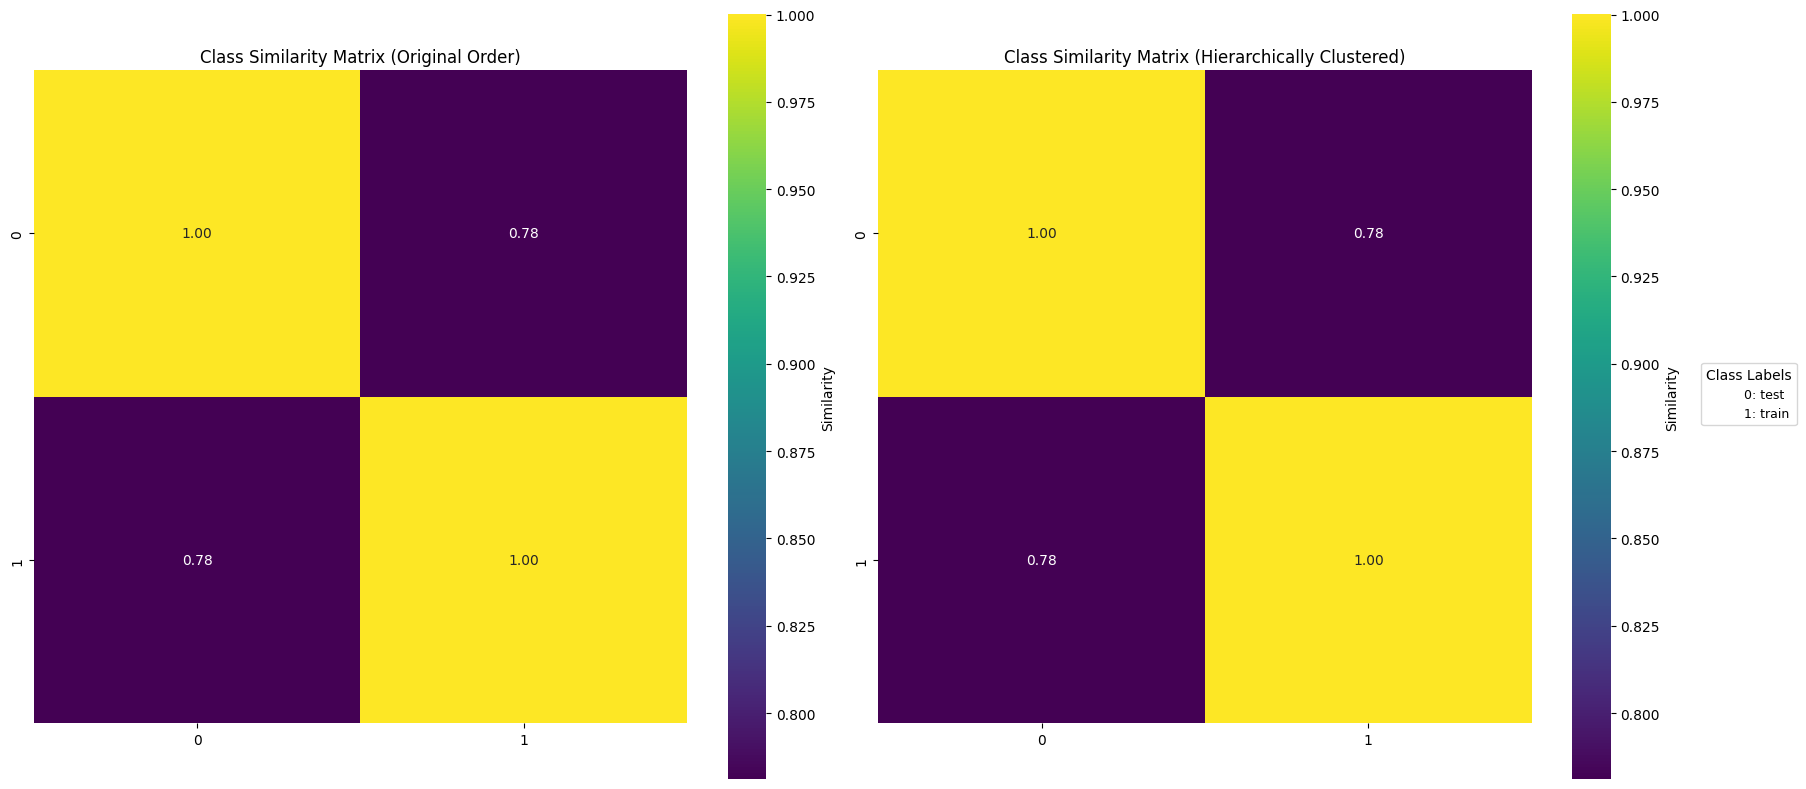

In [ ]:
train_idx, test_idx, obj_val = optimization_split(
    centroids, 
    test_size=0.2, 
    method='simulated_annealing',
    max_iter=100,
    seed=42
)

check_train_test_indices([l for i,l in enumerate(labels) if i in train_idx], 
                         [l for i,l in enumerate(labels) if i in test_idx], 
                         gdf, 
                         centroids, 
                         labels,
                         aez_number_to_class_label)


TRAIN INDICES:
Dominantly very steep terrain:10170 samples(1.684% of total GDF)
TOTAL OF GDF:1.684%
TEST INDICES:
Sub-tropics, mod. cool; sub-humid, no soil/terrain limitations:5072 samples(0.840% of total GDF)
Sub-tropics, mod. cool; sub-humid, with soil/terrain limitations:6908 samples(1.144% of total GDF)
Sub-tropics, mod. cool; humid, no soil/terrain limitations:9878 samples(1.635% of total GDF)
Sub-tropics, mod. cool; humid, with soil/terrain limitations:8764 samples(1.451% of total GDF)
Sub-tropics, cool; sub-humid, no soil/terrain limitations:4639 samples(0.768% of total GDF)
Sub-tropics, cool; sub-humid, with soil/terrain limitations:15116 samples(2.503% of total GDF)
Sub-tropics, cool; humid, no soil/terrain limitations:25142 samples(4.163% of total GDF)
Sub-tropics, cool; humid, with soil/terrain limitations:23801 samples(3.941% of total GDF)
Temperate, moderate; moist, no soil/terrain limitations:191 samples(0.032% of total GDF)
Temperate, moderate; moist, with soil/terrain 

/tmp/ipykernel_123579/2048871702.py:2: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  unique_labels = np.array(torch.unique(y))


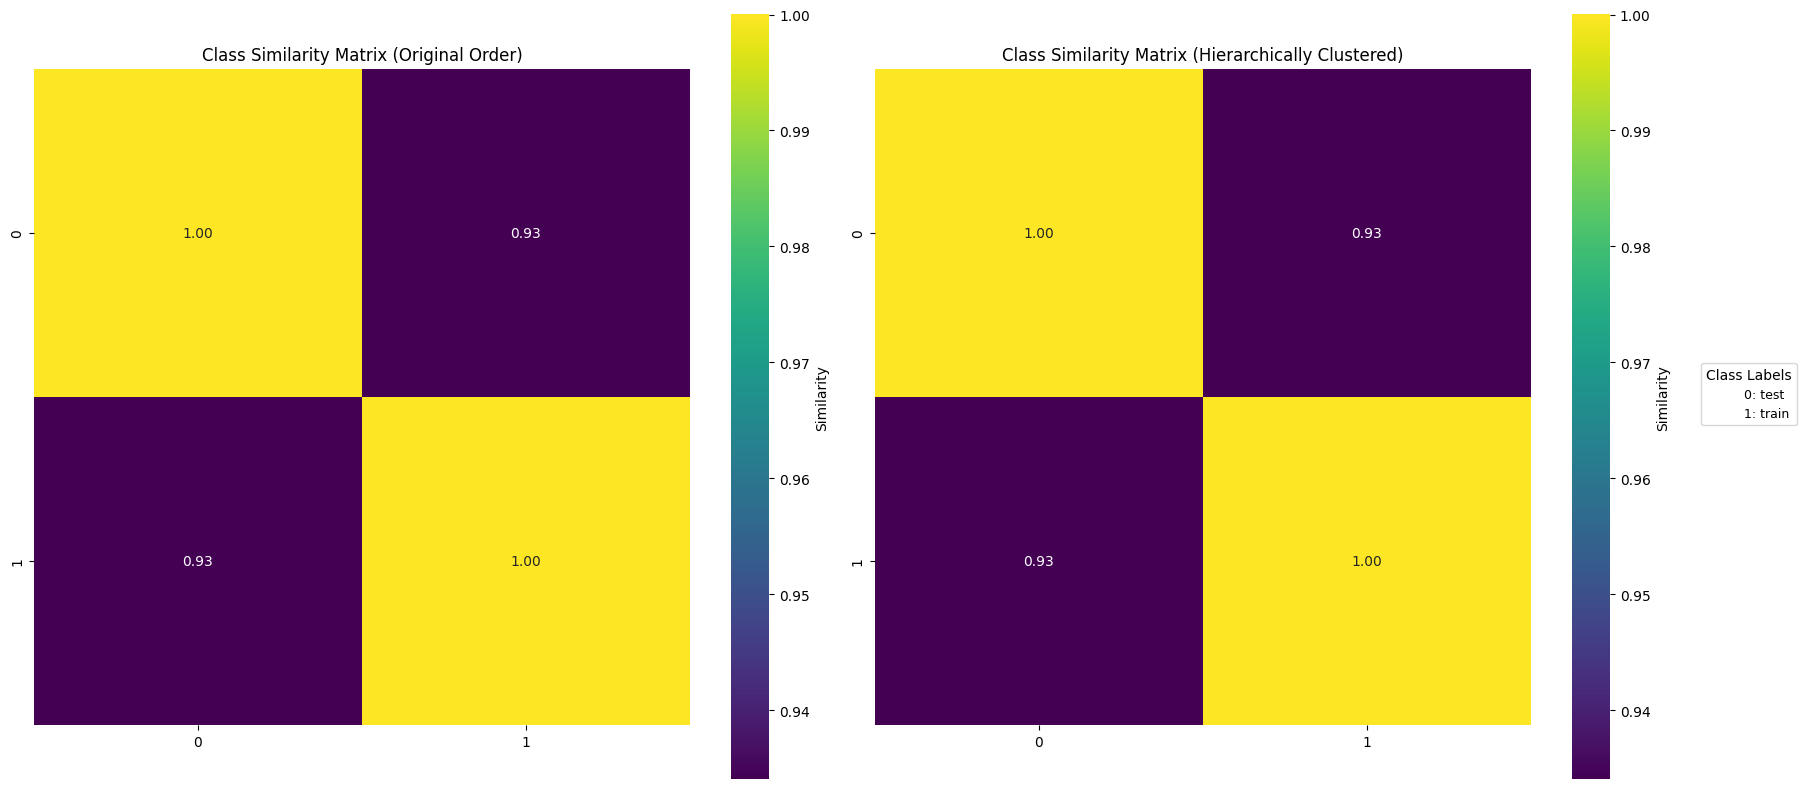

In [ ]:
def minimax_similarity(centroids, labels, gdf, aez_number_to_class_label, test_ratio=0.2):
    from itertools import combinations
    
    n_classes = len(labels)
    n_test = int(n_classes * len(gdf))
    dist_matrix = cosine_similarity(centroids)
    
    best_similarity = float('inf')  # Start with worst case (highest similarity)
    best_split = None
    
    for test_combo in combinations(range(n_classes), n_classes-1):
        test_classes = [aez_number_to_class_label[i] for i in test_combo]
        sub_gdf = gdf[gdf["aez_class"].isin(test_classes)]
        sublen = len(sub_gdf)
        if sublen > n_test:
            continue
        
        test_idx = np.zeros(n_classes, dtype=bool)
        test_idx[list(test_combo)] = True
        train_idx = ~test_idx
        
        cross_similarity = dist_matrix[np.ix_(test_idx, train_idx)]
        max_similarity = cross_similarity.max()  
        
        if max_similarity < best_similarity:
            best_similarity = max_similarity
            best_split = (train_idx, test_idx)
    
    train_indices, test_indices = best_split
    return labels[train_indices], labels[test_indices]

train_indices, test_indices = minimax_similarity(centroids, labels, gdf, aez_number_to_class_label, test_ratio=0.3)
check_train_test_indices(train_indices, test_indices, gdf, centroids, labels, aez_number_to_class_label)

In [ ]:
preds = kmeans.predict(centroids)
class_to_test_or_train = {aez_number_to_class_label[v]:("train" if preds[i] == 0 else "test") for i,v in enumerate(labels)}
class_to_test_or_train["Unclassified"] = "N/A"
gdf["semantically_far_test_or_train"] = gdf["aez_class"].apply(lambda x: class_to_test_or_train[x])

[ 35153 526113  42737]


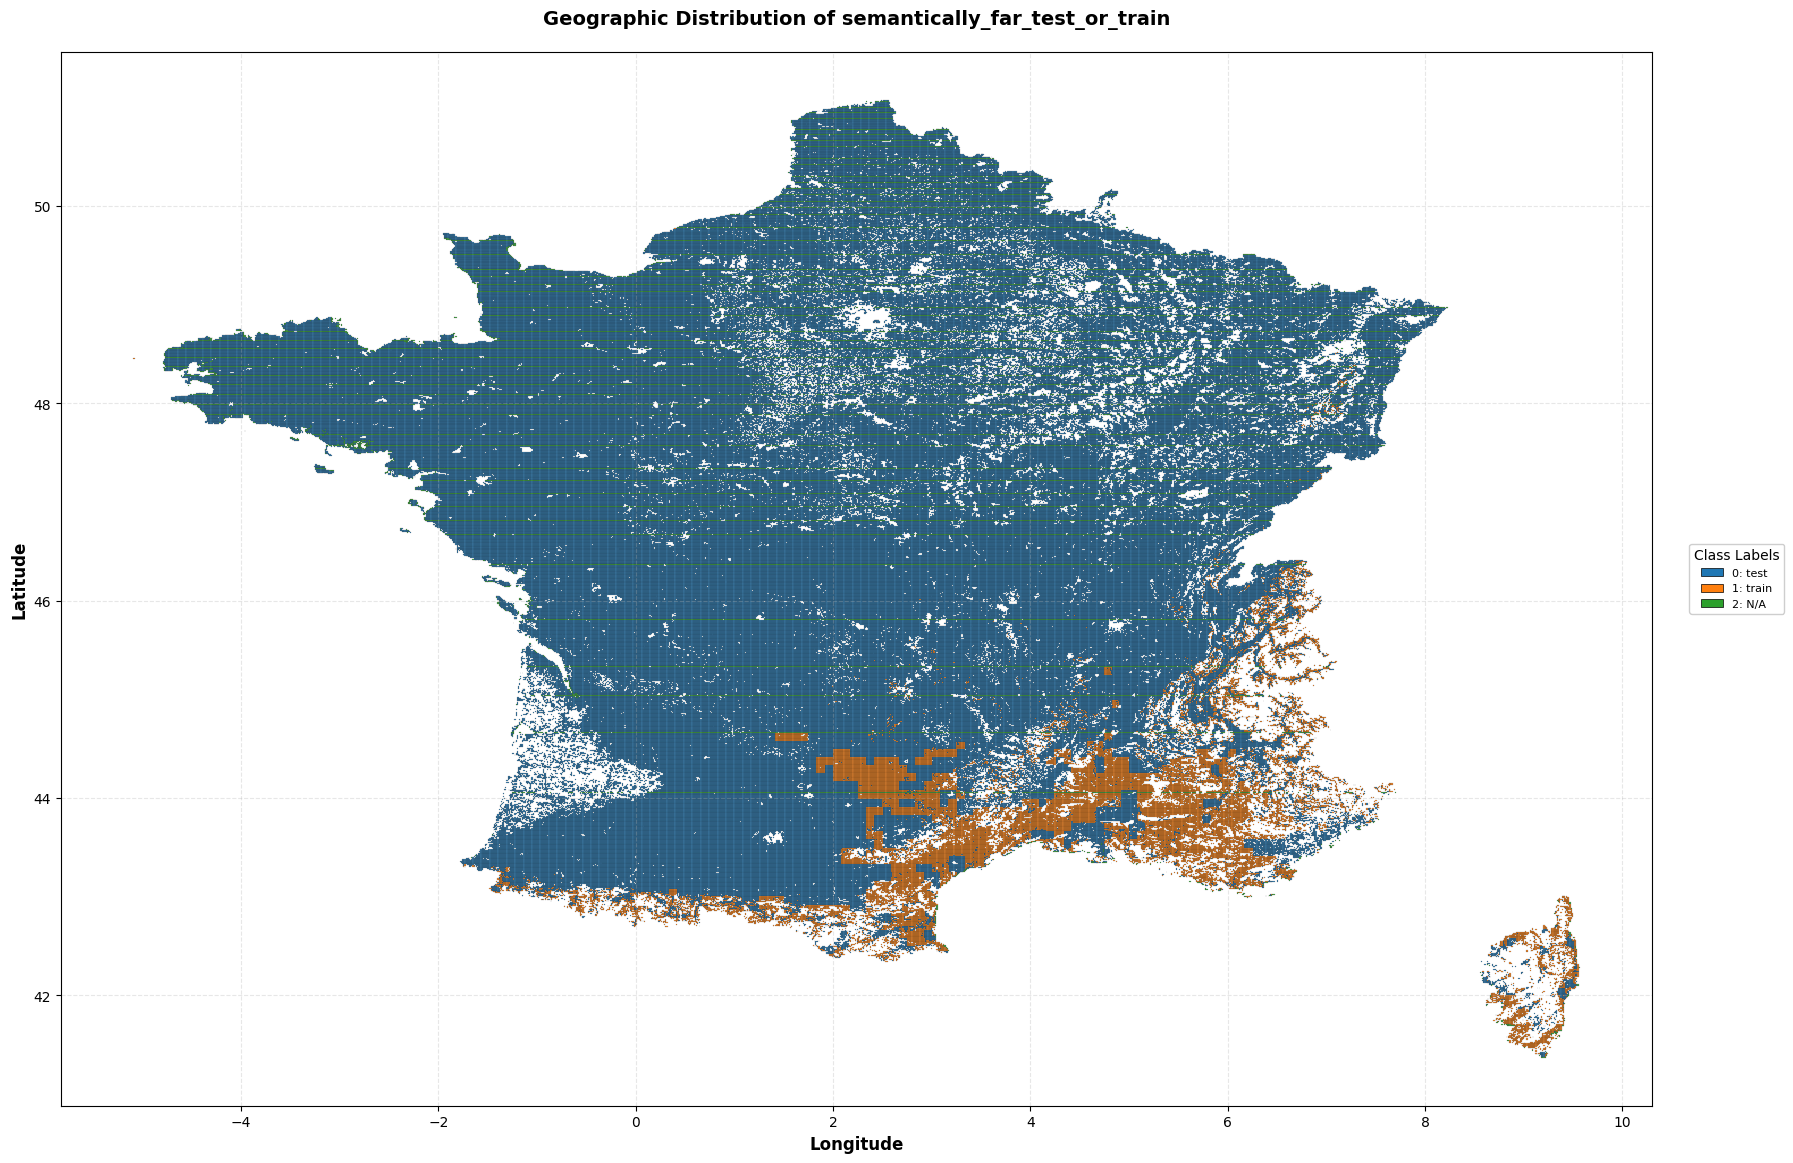


Class distribution summary:
Total points/polygons plotted: 604003

Top 5 classes by count:
  test: 526113 (87.1%)
  train: 42737 (7.1%)
  N/A: 35153 (5.8%)


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
def plot_geographic_distribution(gdf, key="aez_class", title="Geographic Distribution of {}"):
    data = gdf[key]
    if type(data[0]) == np.int64:
        data = data[data >= 0]
    values,counts = np.unique(data, return_counts=True)

    sorted_indices = np.argsort(counts)[::-1]
    sorted_values = values[sorted_indices]
    print(counts)

    n_classes = len(sorted_values)
    if n_classes < 10:
        colors = plt.cm.tab10(np.arange(n_classes))
    else:
        colors = plt.cm.tab20(np.arange(n_classes) % 20)
        if n_classes > 20:
            colors2 = plt.cm.Set3(np.arange(n_classes - 20) % 12)
            colors = np.vstack([colors, colors2])

    class_to_color = {class_name: colors[i] for i, class_name in enumerate(sorted_values)}

    gdf['plot_color'] = gdf[key].map(class_to_color)

    fig, ax = plt.subplots(figsize=(18, 12))

    if gdf.geometry.geom_type.iloc[0] == 'Point':
        for class_name in sorted_values:
            class_data = gdf[gdf[key] == class_name]
            if len(class_data) > 0:
                class_data.plot(ax=ax, 
                            color=class_to_color[class_name],
                            markersize=15,
                            edgecolor='black',
                            linewidth=0.2,
                            alpha=0.7,
                            label=class_name)
    else:
        for class_name in sorted_values:
            class_data = gdf[gdf[key] == class_name]
            if len(class_data) > 0:
                class_data.plot(ax=ax,
                            color=class_to_color[class_name],
                            edgecolor='black',
                            linewidth=0.1,
                            alpha=0.8,
                            label=class_name)

    # Customize the plot
    ax.set_xlabel('Longitude', fontsize=12, fontweight='bold')
    ax.set_ylabel('Latitude', fontsize=12, fontweight='bold')
    ax.set_title(title.format(key), fontsize=14, fontweight='bold', pad=20)
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.set_aspect('equal')

    # Create legend with the same colors and order as histogram
    legend_labels = [f"{i}: {str(label)[:45]}{'...' if len(str(label)) > 45 else ''}" 
                    for i, label in enumerate(sorted_values)]

    # Create custom legend handles
    from matplotlib.patches import Patch
    legend_handles = [Patch(facecolor=colors[i], edgecolor='black', linewidth=0.5) 
                    for i in range(n_classes)]

    ax.legend(legend_handles, legend_labels,
            loc='center left',
            bbox_to_anchor=(1.02, 0.5),
            fontsize=8,
            framealpha=0.95,
            title='Class Labels',
            title_fontsize=10,
            ncol=1)

    plt.tight_layout()
    plt.show()

    # Print class distribution info
    print(f"\nClass distribution summary:")
    print(f"Total points/polygons plotted: {len(gdf)}")
    print(f"\nTop 5 classes by count:")
    for i in range(min(5, len(sorted_values))):
        count = len(gdf[gdf[key] == sorted_values[i]])
        pct = 100 * count / len(gdf)
        print(f"  {sorted_values[i]}: {count} ({pct:.1f}%)")


plot_geographic_distribution(gdf, "semantically_far_test_or_train")